In [5]:
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

### Simple logistic regression

Assume a Bernoulli distribution:

$$p(y_i \mid x_i,\theta) = p_i^{y_i}(1-p_i)^{1-y_i}$$

With $p_i = \sigma(wx_i + b)$

$$p_i = p (y_i = 1 | x_i, w, b) = \sigma ( w x_i + b)$$

In [2]:
x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])

$$\sigma (z) = \frac{1}{1 + e^{-z}}$$
Sigmoid -> always between 0 and 1

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

$$\theta = \begin{pmatrix} w \\ b \end{pmatrix}$$
$w$: weight\
$b$: bias

In [4]:
w = 1.2
b = -0.3

$$\frac{\partial}{\partial w} \log p(y_i \mid x_i,\theta)$$

$$\frac{\partial}{\partial w} = \left(\frac{y_i}{p_i} - \frac{1-y_i}{1-p_i}\right) \frac{\partial p_i}{\partial w}$$

$\frac{d p_i}{d z} = p_i(1-p_i)$

$z = wx_i + b:$ -> $\frac{\partial p_i}{\partial w} = p_i(1-p_i)\, x_i$

$$L = \prod_i p(y_i \mid x_i, \theta)$$

$$\log L = \sum_i \log p(y_i \mid x_i, \theta)$$

$$F_{\alpha\beta} = \mathbb{E}\left[\frac{\partial \log L}{\partial \theta_\alpha} \frac{\partial \log L}{\partial \theta_\beta} \right]$$
Or 
$$F = \sum_{i=1}^N p_i(1-p_i)\, \phi_i \phi_i^T$$

$$\phi_i = \begin{pmatrix} x_i\\ 1 \end{pmatrix}$$

$p_i (1 - p_i)$ -> variance of the distribution

$$F= \sum_{i=1}^N p_i(1-p_i) \begin{pmatrix} x_i^2 & x_i\\ x_i & 1 \end{pmatrix}$$

In [5]:
def fisher_logistic_1d(x, w, b):
    F = np.zeros((2, 2), dtype=float)

    for xi in x:
        p = sigmoid(w * xi + b)
        weight = p * (1 - p)

        phi = np.array([xi, 1.0]).reshape(2, 1)
        F += weight * (phi @ phi.T)

    return F

In [6]:
F = fisher_logistic_1d(x, w, b)
F

array([[0.97945643, 0.13272784],
       [0.13272784, 0.75530749]])

$$\mathrm{Cov} (\theta) \approx F^{-1}$$

$$\Sigma = F^{-1}$$

$$\Sigma = \begin{pmatrix} \text{var}(w) & \text{cov}(w,b) \\ \text{cov}(w,b) & \text{var}(b) \end{pmatrix}$$

In [7]:
cov_approx = np.linalg.inv(F)
cov_approx

array([[ 1.04588006, -0.18378926],
       [-0.18378926,  1.35626082]])

$$\Sigma = \begin{pmatrix} \sigma_w^2 & \text{cov}(w,b) \\ \text{cov}(w,b) & \sigma_b^2 \end{pmatrix}$$

Error in $w$: $\sigma_w = \sqrt{\Sigma_{11}}$

Error en $b$: $\sigma_b = \sqrt{\Sigma_{22}}$

In [8]:
errors = np.sqrt(np.diag(cov_approx))
errors

array([1.02268278, 1.16458611])

Contours

In [9]:
inv_cov = np.linalg.inv(cov_approx)

In [10]:
mu = np.array([w, b])

In [11]:
w_vals = np.linspace(mu[0] - 4, mu[0] + 4, 300)
b_vals = np.linspace(mu[1] - 4, mu[1] + 4, 300)

In [12]:
W, B = np.meshgrid(w_vals, b_vals)

In [13]:
dw = W - mu[0]
db = B - mu[1]

In [14]:
Z = (inv_cov[0,0] * dw**2 + 2 * inv_cov[0,1] * dw * db + inv_cov[1,1] * db**2)

In [29]:
det_cov = np.linalg.det(cov_approx)

In [31]:
P = np.exp(-0.5 * Z) / (2 * np.pi * np.sqrt(det_cov))

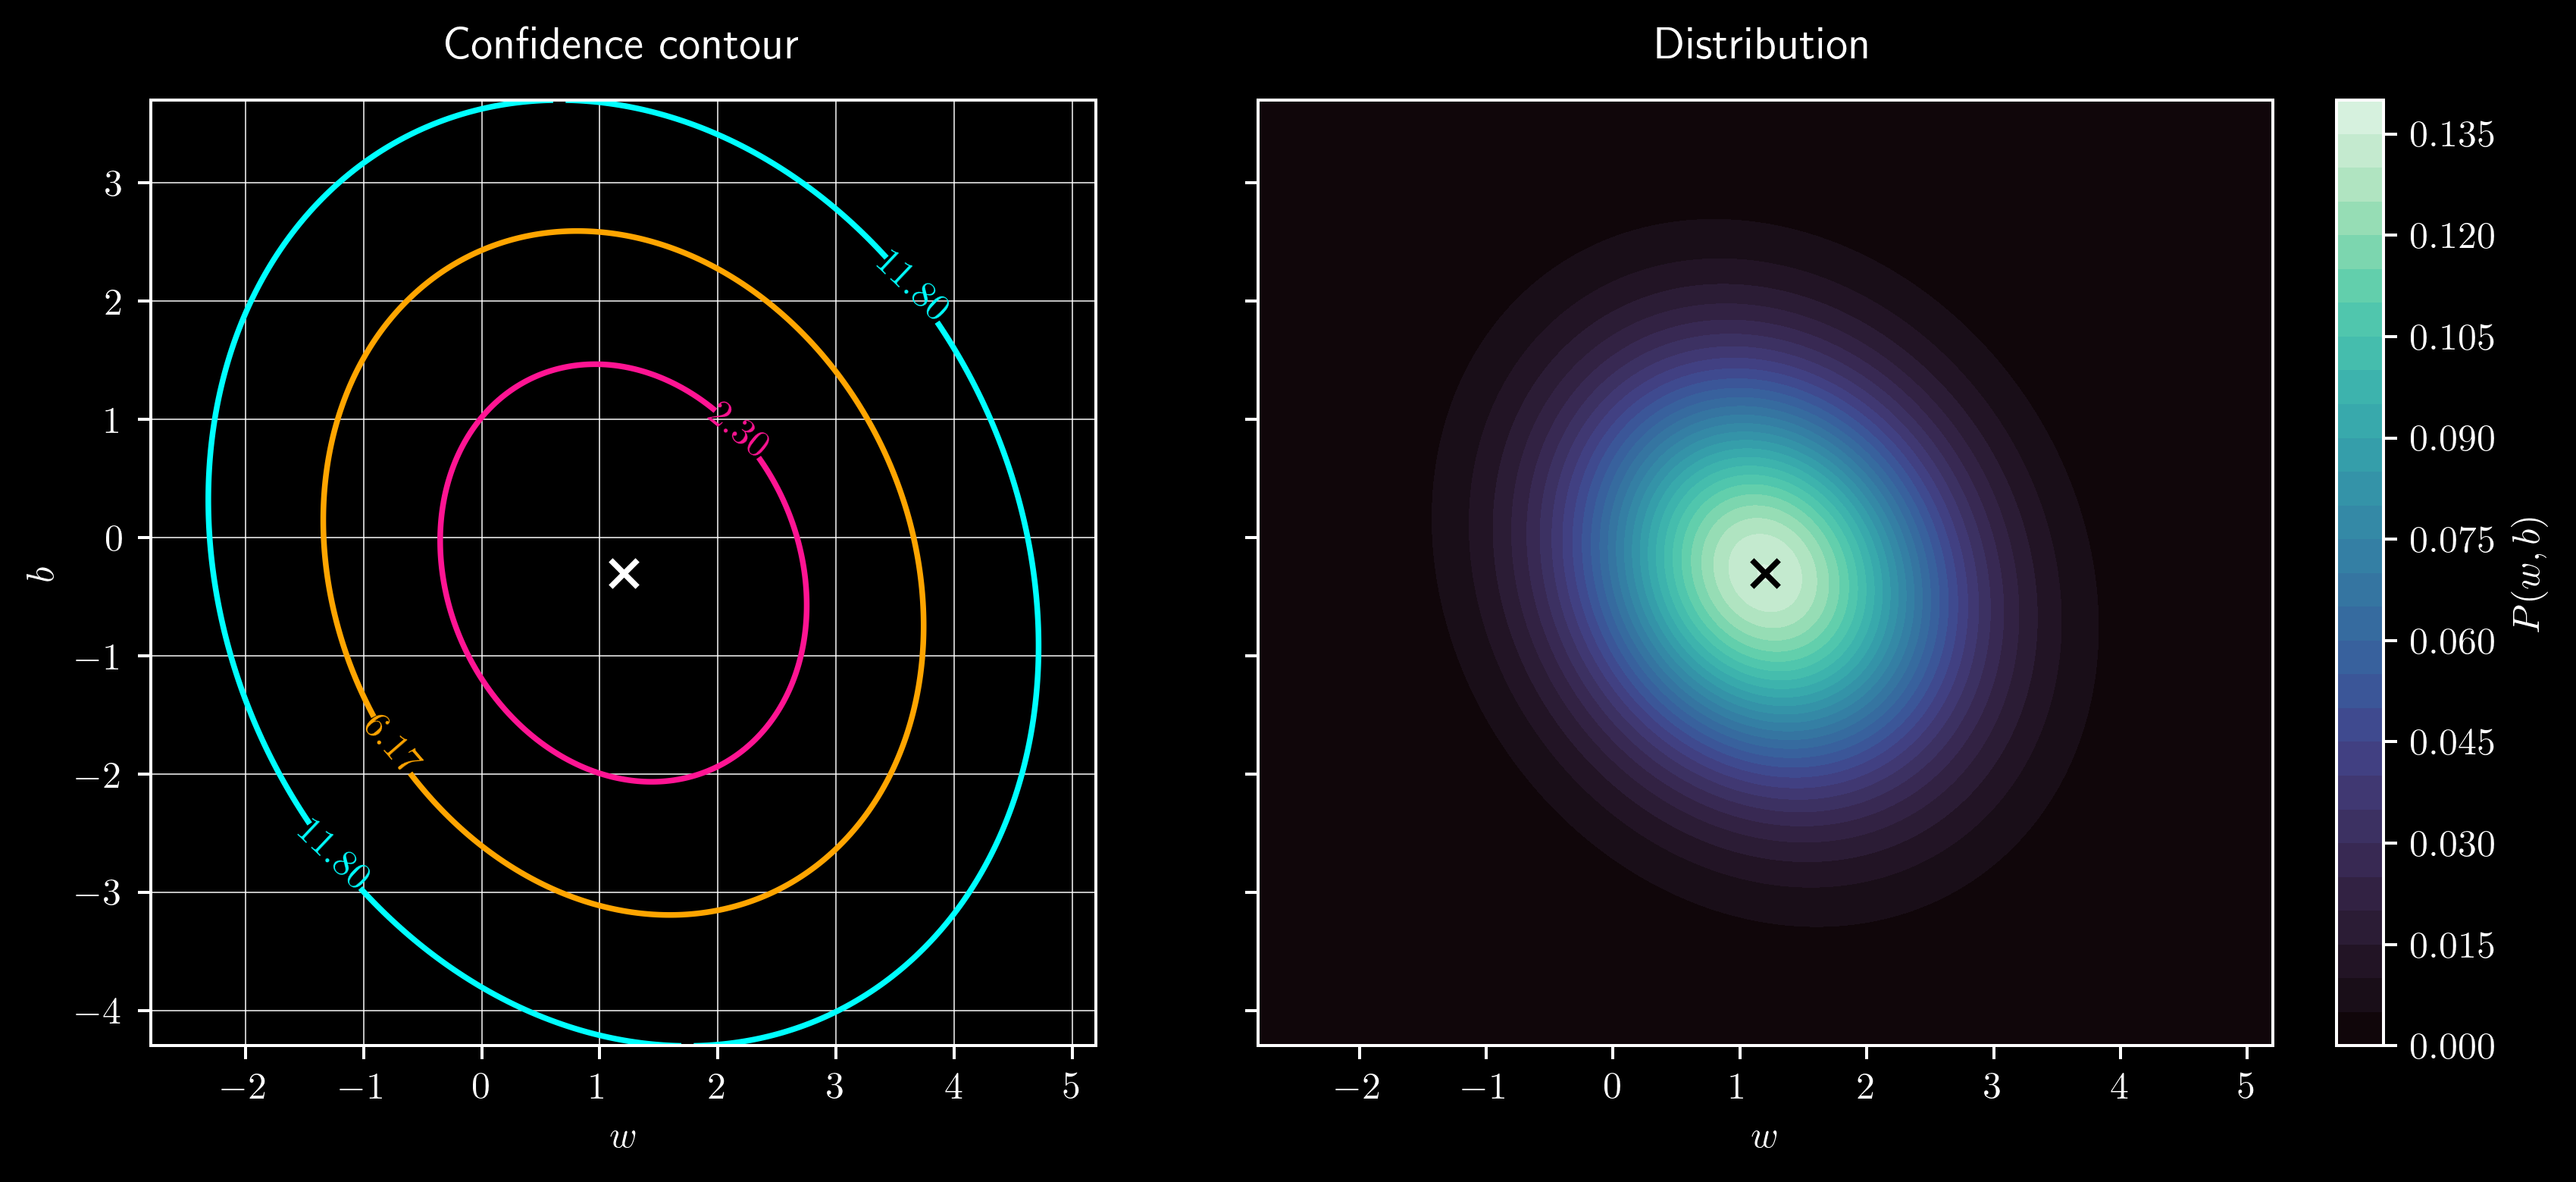

In [75]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0)

axes[0].set_title('Confidence contour', y=1.02)
cs = axes[0].contour(W, B, Z, levels=[2.30, 6.17, 11.8],
                colors=['deeppink', 'orange', 'cyan'],)
axes[0].clabel(cs, inline=True, fontsize=10)
axes[0].scatter(mu[0], mu[1], marker='x', s=50, c='white')
axes[0].set_xlabel('$w$')
axes[0].set_ylabel('$b$')
axes[0].grid(lw=0.3)
axes[0].set_aspect(aspect='equal', adjustable='box')

axes[1].set_title('Distribution', y=1.02)
cf = axes[1].contourf(W, B, P, levels=30, cmap=cmap)
axes[1].scatter(mu[0], mu[1], color='black', marker='x', s=50)
axes[1].set_xlabel('$w$')
# axes[1].set_ylabel('$b$')
# axes[1].set_aspect(aspect='equal', adjustable='box')
fig.colorbar(cf, ax=axes[1], label='$P(w,b)$')

plt.show()

### Non linear example, 3 var -> regression

$$\mu(x;\theta)=A\,e^{-kx}+c$$

With
$$\theta = (A,k,c)$$

In [1]:
def model(x, A, k, c):
    return A * np.exp(-k * x) + c

Observed data follows:

$$y_i \sim \mathcal{N}(\mu(x_i;\theta),\sigma^2)$$
Gaussian noise with known std $\sigma$

In [6]:
rng = np.random.default_rng(42)

Known parameters:

$$A_{0}=2.5$$

$$\quad k_{0}=0.8$$

$$\quad c_{0}=0.4$$

In [7]:
A_true = 2.5
k_true = 0.8
c_true = 0.4

And $$\sigma = 0.15$$

In [8]:
sigma = 0.15

In [10]:
x = np.linspace(0, 4, 40)

In [11]:
y_true = model(x, A_true, k_true, c_true)
y_obs = y_true + rng.normal(0, sigma, size=len(x))

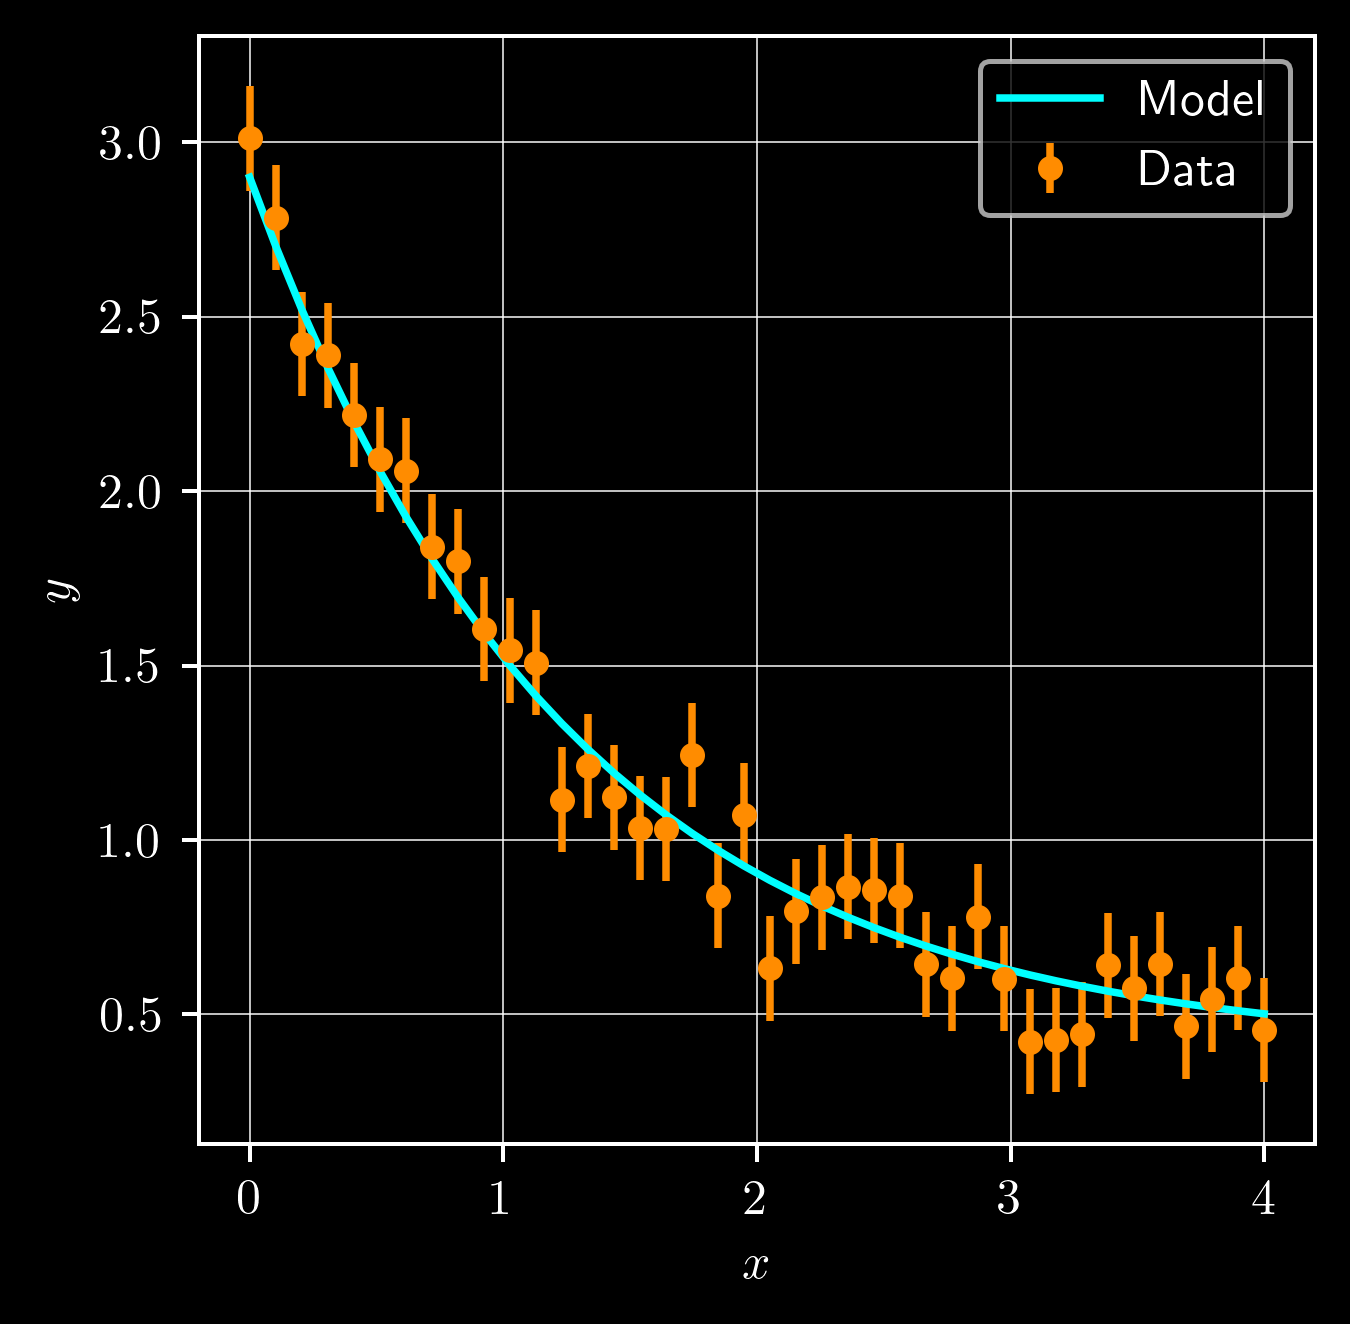

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.errorbar(x, y_obs, yerr=sigma, fmt='o', ms=4, label='Data', c='darkorange')
ax.plot(x, y_true, label='Model', c='cyan')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

plt.legend()
plt.grid(lw=0.3)
plt.show()

Gaussian likelihood with known variance:

$$F_{\alpha\beta} = \frac{1}{\sigma^2} \sum_{i=1}^N \frac{\partial \mu(x_i)}{\partial \theta_\alpha} \frac{\partial \mu(x_i)}{\partial \theta_\beta}$$

$$\frac{\partial \mu}{\partial A} = e^{-kx}$$

$$\frac{\partial \mu}{\partial k} = A\frac{d}{dk}(e^{-kx}) = -Ax\,e^{-kx}$$

$$\frac{\partial \mu}{\partial c} = 1$$

In [17]:
def grad_model(x, A, k, c):
    dA = np.exp(-k * x)
    dk = -A * x * np.exp(-k * x)
    dc = np.ones_like(x)
    return np.vstack([dA, dk, dc]).T

$$g_i = \begin{pmatrix} e^{-k x_i}\\ - A x_i e^{-k x_i}\\ 1 \end{pmatrix}$$

$$F = \frac{1}{\sigma^2}\sum_{i=1}^N g_i g_i^T$$

The matrix would be

$$F= \frac{1}{\sigma^2}\sum_{i=1}^N \begin{pmatrix} e^{-2kx_i} & - A x_i e^{-2kx_i} & e^{-kx_i} \\ - A x_i e^{-2kx_i} & A^2 x_i^2 e^{-2kx_i} & - A x_i e^{-kx_i} \\ e^{-kx_i} & - A x_i e^{-kx_i} & 1 \end{pmatrix}$$

In [18]:
def fisher_matrix_exp(x, sigma, A, k, c):
    G = grad_model(x, A, k, c)
    F = (G.T @ G) / sigma**2
    return F

$$F = \frac{1}{\sigma^2} G^T G$$
Where $G$ contains all gradients

In [20]:
F = fisher_matrix_exp(x, sigma, A_true, k_true, c_true)
F #3x3

array([[  293.24897919,  -417.3862257 ,   543.00666205],
       [ -417.3862257 ,  1264.78686895, -1410.93829662],
       [  543.00666205, -1410.93829662,  1777.77777778]])

$$\Sigma \approx F^{-1}$$

In [22]:
cov = np.linalg.inv(F)
cov

array([[ 0.00792884, -0.00074221, -0.00301085],
       [-0.00074221,  0.00696642,  0.00575562],
       [-0.00301085,  0.00575562,  0.0060501 ]])

$$\sigma_A = \sqrt{\Sigma_{AA}},\quad \sigma_k = \sqrt{\Sigma_{kk}},\quad \sigma_c = \sqrt{\Sigma_{cc}}$$

In [24]:
errors = np.sqrt(np.diag(cov))
errors

array([0.08904404, 0.08346509, 0.07778241])

In [26]:
param_names = ['A', 'k', 'c']

print('Fisher matrix')
for i in range(3):
    for j in range(3):
        print(f'F[{param_names[i]},{param_names[j]}] = {F[i,j]:.6f}')

Fisher matrix
F[A,A] = 293.248979
F[A,k] = -417.386226
F[A,c] = 543.006662
F[k,A] = -417.386226
F[k,k] = 1264.786869
F[k,c] = -1410.938297
F[c,A] = 543.006662
F[c,k] = -1410.938297
F[c,c] = 1777.777778


In [27]:
print('Covariance matrix')
for i in range(3):
    for j in range(3):
        print(f"Cov[{param_names[i]},{param_names[j]}] = {cov[i,j]:.6f}")

Covariance matrix
Cov[A,A] = 0.007929
Cov[A,k] = -0.000742
Cov[A,c] = -0.003011
Cov[k,A] = -0.000742
Cov[k,k] = 0.006966
Cov[k,c] = 0.005756
Cov[c,A] = -0.003011
Cov[c,k] = 0.005756
Cov[c,c] = 0.006050


Correlation matrix:

$$\rho_{ij}=\frac{\Sigma_{ij}}{\sigma_i\sigma_j}$$

Near 0 -> No correlation

In [30]:
std = np.sqrt(np.diag(cov))

In [31]:
corr = cov / np.outer(std, std)
corr

array([[ 1.        , -0.09986595, -0.4347136 ],
       [-0.09986595,  1.        ,  0.88655555],
       [-0.4347136 ,  0.88655555,  1.        ]])

Contour plot -> Error ellipses

In [32]:
mu_Ak = np.array([A_true, k_true])
cov_Ak = cov[:2, :2]
inv_cov_Ak = np.linalg.inv(cov_Ak)

In [33]:
A_vals = np.linspace(A_true - 4*errors[0], A_true + 4*errors[0], 300)
k_vals = np.linspace(k_true - 4*errors[1], k_true + 4*errors[1], 300)

In [34]:
AA, KK = np.meshgrid(A_vals, k_vals)

In [35]:
dA = AA - mu_Ak[0]
dK = KK - mu_Ak[1]

In [36]:
Z = (inv_cov_Ak[0,0] * dA**2 + 2 * inv_cov_Ak[0,1] * dA * dK + inv_cov_Ak[1,1] * dK**2)

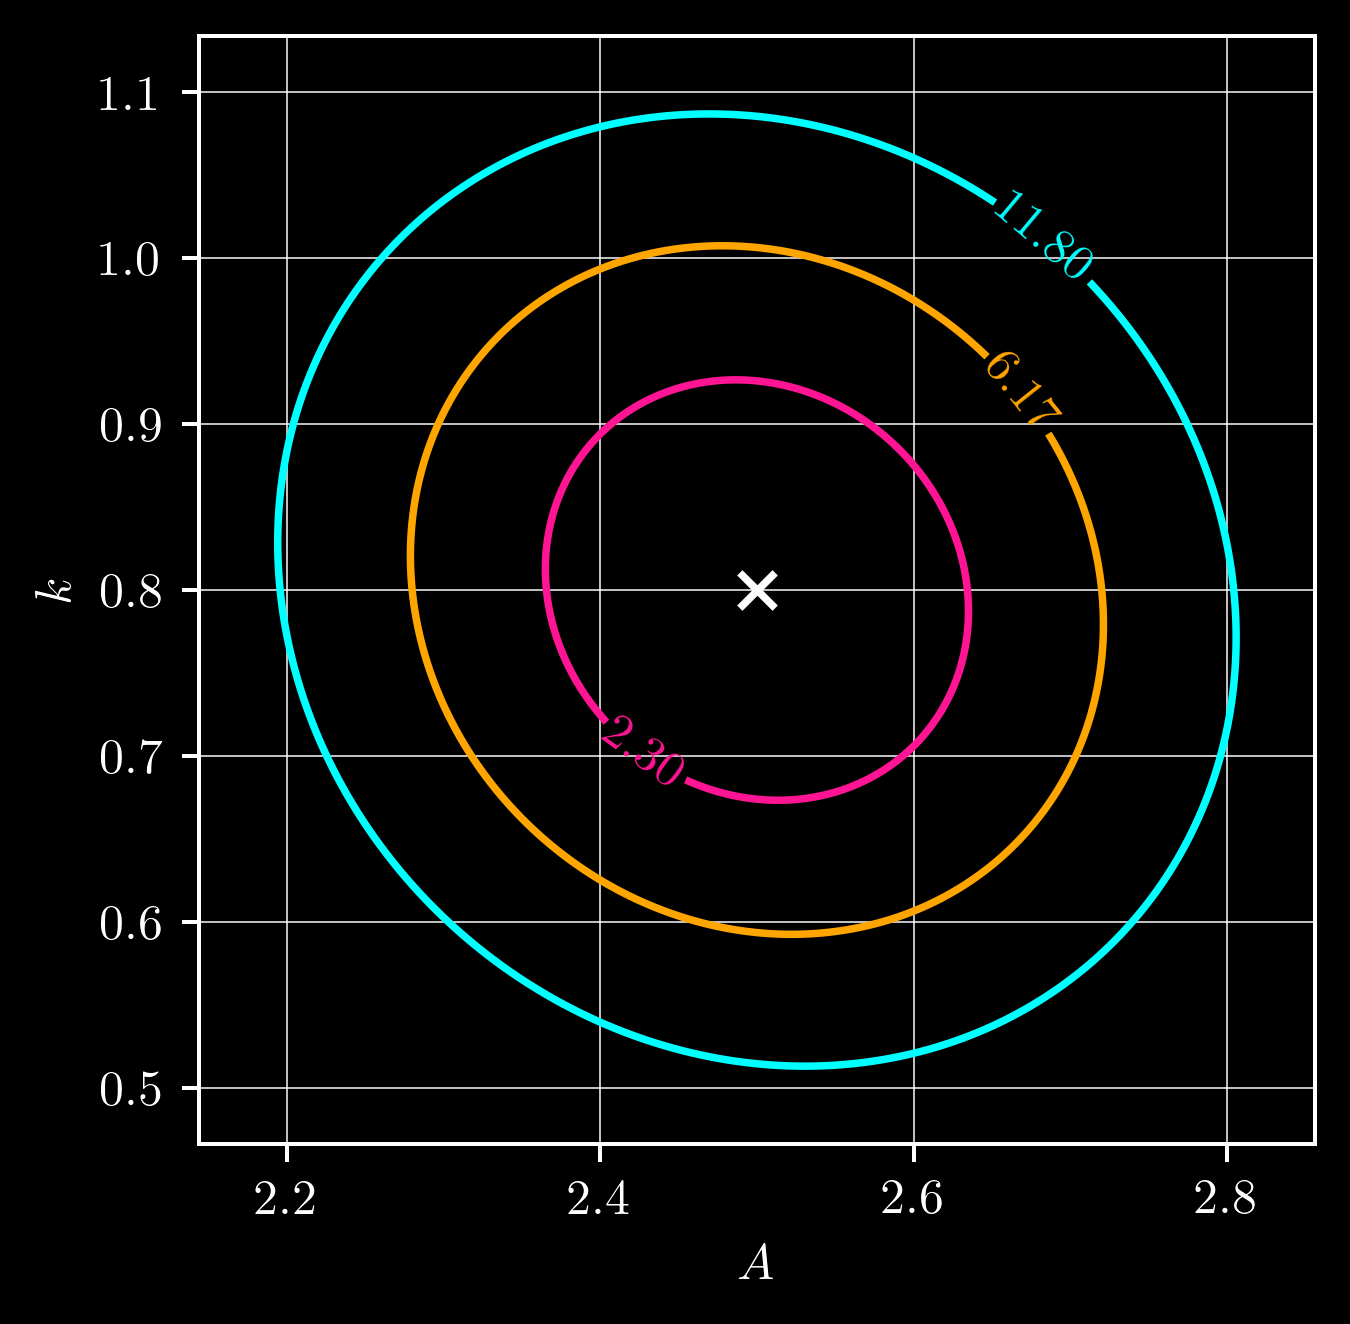

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))

cs = ax.contour(AA, KK, Z, levels=[2.30, 6.17, 11.8],
           colors=['deeppink', 'orange', 'cyan'])
ax.clabel(cs, inline=True, fontsize=10)

ax.scatter(A_true, k_true, color='white', marker='x', s=50)

ax.set_xlabel('$A$')
ax.set_ylabel('$k$')

plt.grid(lw=0.3)
plt.show()